In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('API_NGA_DS2_en_csv_v2_279569.csv', skiprows=4)
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Nigeria,NGA,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.439871e+01,NaN,NaN,NaN
1,Nigeria,NGA,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,...,1.879000e+03,1.173000e+03,1.326000e+03,2.001000e+03,1.999000e+03,1.535000e+03,2.084000e+03,1486.0,NaN,NaN
2,Nigeria,NGA,High-technology exports (current US$),TX.VAL.TECH.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.831564e+07,4.164509e+07,8.542468e+07,1.903267e+08,1.959472e+08,7.666815e+07,6.516024e+07,50082370.0,NaN,NaN
3,Nigeria,NGA,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.WR.ZS,0.775946,0.965074,3.007684,3.167155,3.263158,1.811543,...,2.523985e+01,2.518154e+01,2.457845e+01,1.933224e+01,1.285259e+01,2.778109e+01,1.020689e+01,NaN,NaN,NaN
4,Nigeria,NGA,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R5.ZS,0.339476,0.390625,0.087816,0.254154,0.350877,0.084258,...,1.505421e+01,1.524678e+01,1.488503e+01,1.554038e+01,1.675164e+01,8.603976e+00,8.780522e+00,NaN,NaN,NaN


In [2]:
print(df.columns.tolist())
print(df.shape)

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']
(1486, 71)


In [3]:
print(df['Indicator Name'].unique())

['Intentional homicides, male (per 100,000 male)'
 'Battle-related deaths (number of people)'
 'High-technology exports (current US$)' ...
 'Urban land area where elevation is below 5 meters (sq. km)'
 'Land under cereal production (hectares)'
 'Agricultural land (% of land area)']


In [4]:
indicators_needed = [
    'GDP growth (annual %)',
    'Inflation, consumer prices (annual %)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'Poverty headcount ratio at national poverty lines (% of population)',
    'Official exchange rate (LCU per US$, period average)',
    'Foreign direct investment, net inflows (% of GDP)',
    'Central government debt, total (% of GDP)',
    'Oil rents (% of GDP)',
    'Population, total',
    'GDP per capita (current US$)',
    'General government final consumption expenditure (% of GDP)'
]

df_filtered = df[df['Indicator Name'].isin(indicators_needed)]
print(df_filtered['Indicator Name'].unique())
print(df_filtered.shape)

['GDP per capita (current US$)' 'Population, total'
 'Central government debt, total (% of GDP)'
 'Inflation, consumer prices (annual %)'
 'General government final consumption expenditure (% of GDP)'
 'Foreign direct investment, net inflows (% of GDP)'
 'Official exchange rate (LCU per US$, period average)'
 'Oil rents (% of GDP)' 'GDP growth (annual %)'
 'Unemployment, total (% of total labor force) (modeled ILO estimate)'
 'Poverty headcount ratio at national poverty lines (% of population)']
(11, 71)


In [5]:
## Reshapeing the  data from wide to long format

df_melted = df_filtered.melt(
    id_vars=['Indicator Name'],
    value_vars=[str(y) for y in range(1960, 2024)],
    var_name='Year',
    value_name='Value'
)
df_melted['Year'] = df_melted['Year'].astype(int)
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')
print(df_melted.head())
print(df_melted.shape)

                                      Indicator Name  Year         Value
0                       GDP per capita (current US$)  1960  9.313701e+01
1                                  Population, total  1960  4.505378e+07
2          Central government debt, total (% of GDP)  1960           NaN
3              Inflation, consumer prices (annual %)  1960  5.444327e+00
4  General government final consumption expenditu...  1960           NaN
(704, 3)


In [6]:
## Creating separate dataframes for each indicator

gdp_growth = df_melted[df_melted['Indicator Name'] == 'GDP growth (annual %)'].dropna()
inflation = df_melted[df_melted['Indicator Name'] == 'Inflation, consumer prices (annual %)'].dropna()
unemployment = df_melted[df_melted['Indicator Name'] == 'Unemployment, total (% of total labor force) (modeled ILO estimate)'].dropna()
poverty = df_melted[df_melted['Indicator Name'] == 'Poverty headcount ratio at national poverty lines (% of population)'].dropna()
exchange_rate = df_melted[df_melted['Indicator Name'] == 'Official exchange rate (LCU per US$, period average)'].dropna()
fdi = df_melted[df_melted['Indicator Name'] == 'Foreign direct investment, net inflows (% of GDP)'].dropna()
debt = df_melted[df_melted['Indicator Name'] == 'Central government debt, total (% of GDP)'].dropna()
oil_rents = df_melted[df_melted['Indicator Name'] == 'Oil rents (% of GDP)'].dropna()
gdp_per_capita = df_melted[df_melted['Indicator Name'] == 'GDP per capita (current US$)'].dropna()
population = df_melted[df_melted['Indicator Name'] == 'Population, total'].dropna()
govt_spending = df_melted[df_melted['Indicator Name'] == 'General government final consumption expenditure (% of GDP)'].dropna()

print('All indicators extracted successfully')

All indicators extracted successfully


In [7]:
##   analyzing the data


In [8]:
##   GDP Growth Analysis

print("=== GDP GROWTH ANALYSIS ===")
print(f"Highest GDP Growth: {gdp_growth['Value'].max():.2f}% in {int(gdp_growth.loc[gdp_growth['Value'].idxmax(), 'Year'])}")
print(f"Lowest GDP Growth: {gdp_growth['Value'].min():.2f}% in {int(gdp_growth.loc[gdp_growth['Value'].idxmin(), 'Year'])}")
print(f"Average GDP Growth: {gdp_growth['Value'].mean():.2f}%")

=== GDP GROWTH ANALYSIS ===
Highest GDP Growth: 25.01% in 1970
Lowest GDP Growth: -15.74% in 1967
Average GDP Growth: 3.57%


In [9]:
##  Inflation Analysis

print("=== INFLATION ANALYSIS ===")
print(f"Highest Inflation: {inflation['Value'].max():.2f}% in {int(inflation.loc[inflation['Value'].idxmax(), 'Year'])}")
print(f"Lowest Inflation: {inflation['Value'].min():.2f}% in {int(inflation.loc[inflation['Value'].idxmin(), 'Year'])}")
print(f"Average Inflation: {inflation['Value'].mean():.2f}%")

=== INFLATION ANALYSIS ===
Highest Inflation: 72.84% in 1995
Lowest Inflation: -3.73% in 1967
Average Inflation: 15.99%


In [10]:
## Exchange Rate Analysis

print("=== EXCHANGE RATE ANALYSIS ===")
print(f"Exchange Rate in 2000: {exchange_rate[exchange_rate['Year']==2000]['Value'].values[0]:.2f} Naira per Dollar")
print(f"Exchange Rate in 2023: {exchange_rate[exchange_rate['Year']==2023]['Value'].values[0]:.2f} Naira per Dollar")
print(f"Naira Depreciation: {((exchange_rate[exchange_rate['Year']==2023]['Value'].values[0] - exchange_rate[exchange_rate['Year']==2000]['Value'].values[0]) / exchange_rate[exchange_rate['Year']==2000]['Value'].values[0] * 100):.2f}%")

=== EXCHANGE RATE ANALYSIS ===
Exchange Rate in 2000: 101.70 Naira per Dollar
Exchange Rate in 2023: 645.19 Naira per Dollar
Naira Depreciation: 534.43%


In [11]:
##  Unemployment Analysis

print("=== UNEMPLOYMENT ANALYSIS ===")
print(f"Highest Unemployment: {unemployment['Value'].max():.2f}% in {int(unemployment.loc[unemployment['Value'].idxmax(), 'Year'])}")
print(f"Lowest Unemployment: {unemployment['Value'].min():.2f}% in {int(unemployment.loc[unemployment['Value'].idxmin(), 'Year'])}")
print(f"Average Unemployment: {unemployment['Value'].mean():.2f}%")

=== UNEMPLOYMENT ANALYSIS ===
Highest Unemployment: 5.71% in 2020
Lowest Unemployment: 3.07% in 2023
Average Unemployment: 4.06%


In [12]:
##  GDP Per Capita Analysis

print("=== GDP PER CAPITA ANALYSIS ===")
print(f"GDP Per Capita in 2000: ${gdp_per_capita[gdp_per_capita['Year']==2000]['Value'].values[0]:,.2f}")
print(f"GDP Per Capita in 2023: ${gdp_per_capita[gdp_per_capita['Year']==2023]['Value'].values[0]:,.2f}")
print(f"Highest GDP Per Capita: ${gdp_per_capita['Value'].max():,.2f} in {int(gdp_per_capita.loc[gdp_per_capita['Value'].idxmax(), 'Year'])}")

=== GDP PER CAPITA ANALYSIS ===
GDP Per Capita in 2000: $547.32
GDP Per Capita in 2023: $2,138.76
Highest GDP Per Capita: $3,189.81 in 2019


In [13]:
##  Oil Rents vs Government Spending

print("=== OIL RENTS VS GOVERNMENT SPENDING ===")
print(f"Average Oil Rents: {oil_rents['Value'].mean():.2f}% of GDP")
print(f"Average Government Spending: {govt_spending['Value'].mean():.2f}% of GDP")
print(f"Highest Oil Rents: {oil_rents['Value'].max():.2f}% in {int(oil_rents.loc[oil_rents['Value'].idxmax(), 'Year'])}")

=== OIL RENTS VS GOVERNMENT SPENDING ===
Average Oil Rents: 12.34% of GDP
Average Government Spending: nan% of GDP
Highest Oil Rents: 40.91% in 1979


In [14]:
##  COVID Impact Analysis

print("=== COVID-19 ECONOMIC IMPACT ===")
print(f"GDP Growth 2019 (Pre-COVID): {gdp_growth[gdp_growth['Year']==2019]['Value'].values[0]:.2f}%")
print(f"GDP Growth 2020 (COVID Year): {gdp_growth[gdp_growth['Year']==2020]['Value'].values[0]:.2f}%")
print(f"GDP Growth 2021 (Recovery): {gdp_growth[gdp_growth['Year']==2021]['Value'].values[0]:.2f}%")
print(f"Inflation 2019: {inflation[inflation['Year']==2019]['Value'].values[0]:.2f}%")
print(f"Inflation 2020: {inflation[inflation['Year']==2020]['Value'].values[0]:.2f}%")
print(f"Inflation 2021: {inflation[inflation['Year']==2021]['Value'].values[0]:.2f}%")

=== COVID-19 ECONOMIC IMPACT ===
GDP Growth 2019 (Pre-COVID): 2.21%
GDP Growth 2020 (COVID Year): -6.37%
GDP Growth 2021 (Recovery): 1.11%
Inflation 2019: 11.40%
Inflation 2020: 13.25%
Inflation 2021: 16.95%


In [15]:
##  Visualization

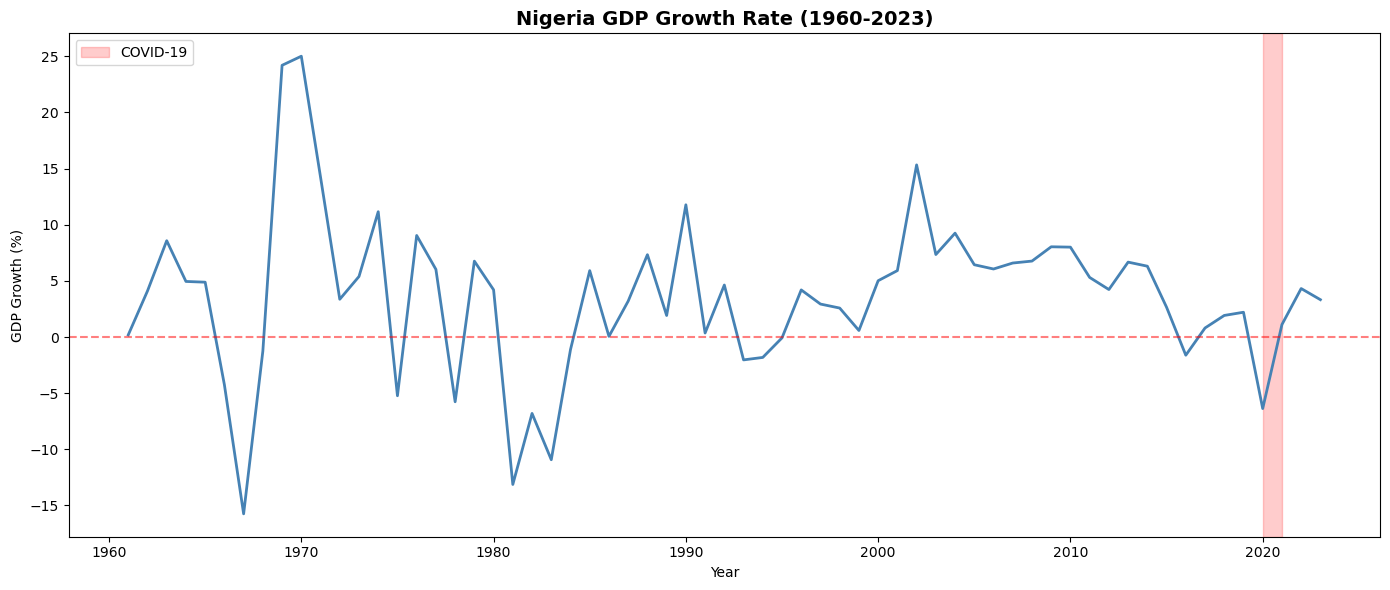

In [16]:
##  GDP Growth Over Time

plt.figure(figsize=(14,6))
plt.plot(gdp_growth['Year'], gdp_growth['Value'], color='steelblue', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.axvspan(2020, 2021, alpha=0.2, color='red', label='COVID-19')
plt.title('Nigeria GDP Growth Rate (1960-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.tight_layout()
plt.show()

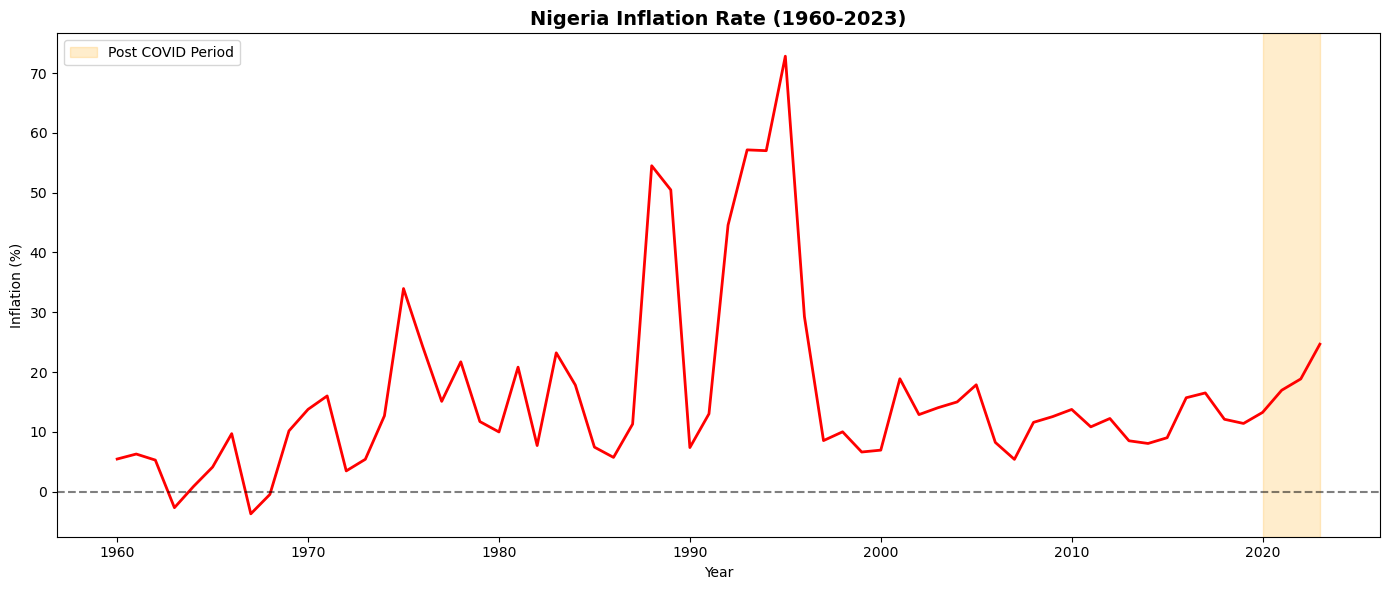

In [17]:
##  Inflation Over Time

plt.figure(figsize=(14,6))
plt.plot(inflation['Year'], inflation['Value'], color='red', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvspan(2020, 2023, alpha=0.2, color='orange', label='Post COVID Period')
plt.title('Nigeria Inflation Rate (1960-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.legend()
plt.tight_layout()
plt.show()

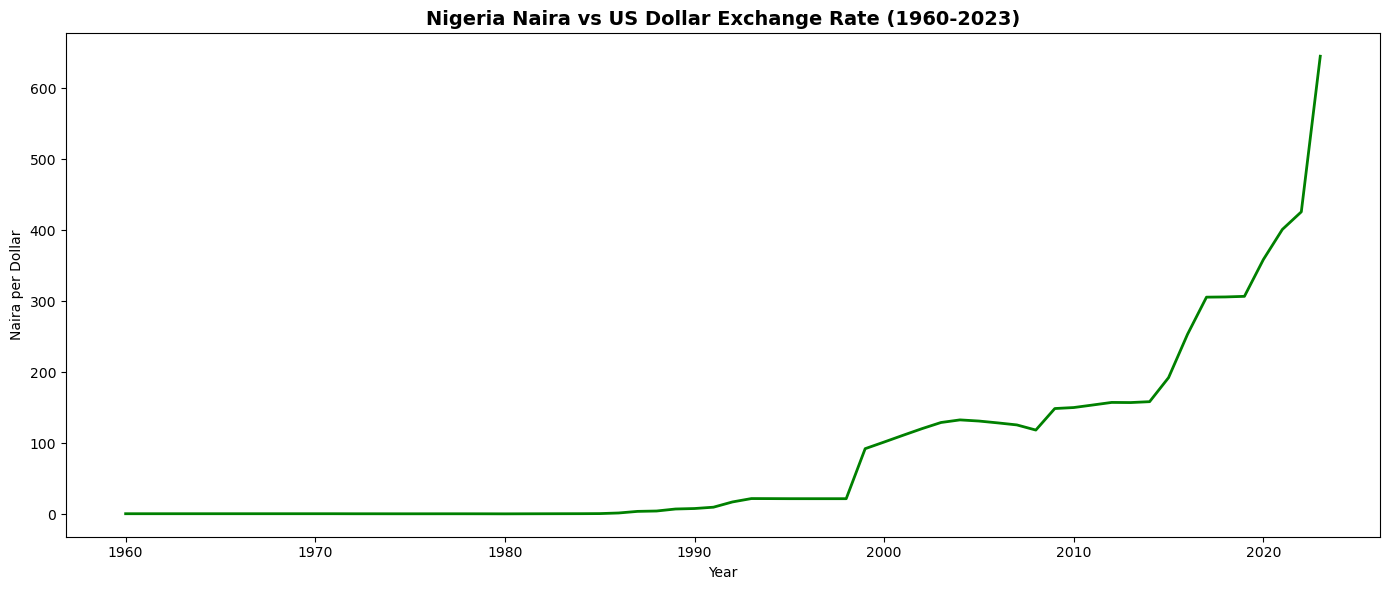

In [18]:
##   Naira vs Dollar Exchange Rate

plt.figure(figsize=(14,6))
plt.plot(exchange_rate['Year'], exchange_rate['Value'], color='green', linewidth=2)
plt.title('Nigeria Naira vs US Dollar Exchange Rate (1960-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Naira per Dollar')
plt.tight_layout()
plt.show()

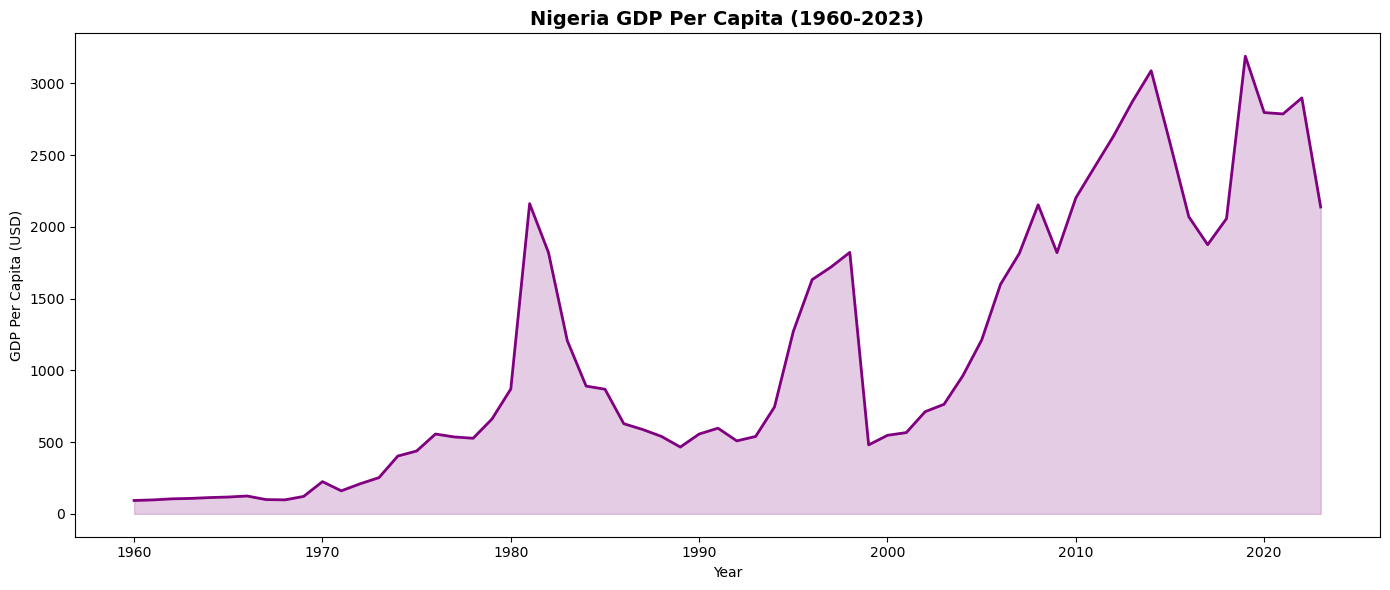

In [19]:
##   GDP Per Capita Over Time

plt.figure(figsize=(14,6))
plt.plot(gdp_per_capita['Year'], gdp_per_capita['Value'], color='purple', linewidth=2)
plt.fill_between(gdp_per_capita['Year'], gdp_per_capita['Value'], alpha=0.2, color='purple')
plt.title('Nigeria GDP Per Capita (1960-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP Per Capita (USD)')
plt.tight_layout()
plt.show()

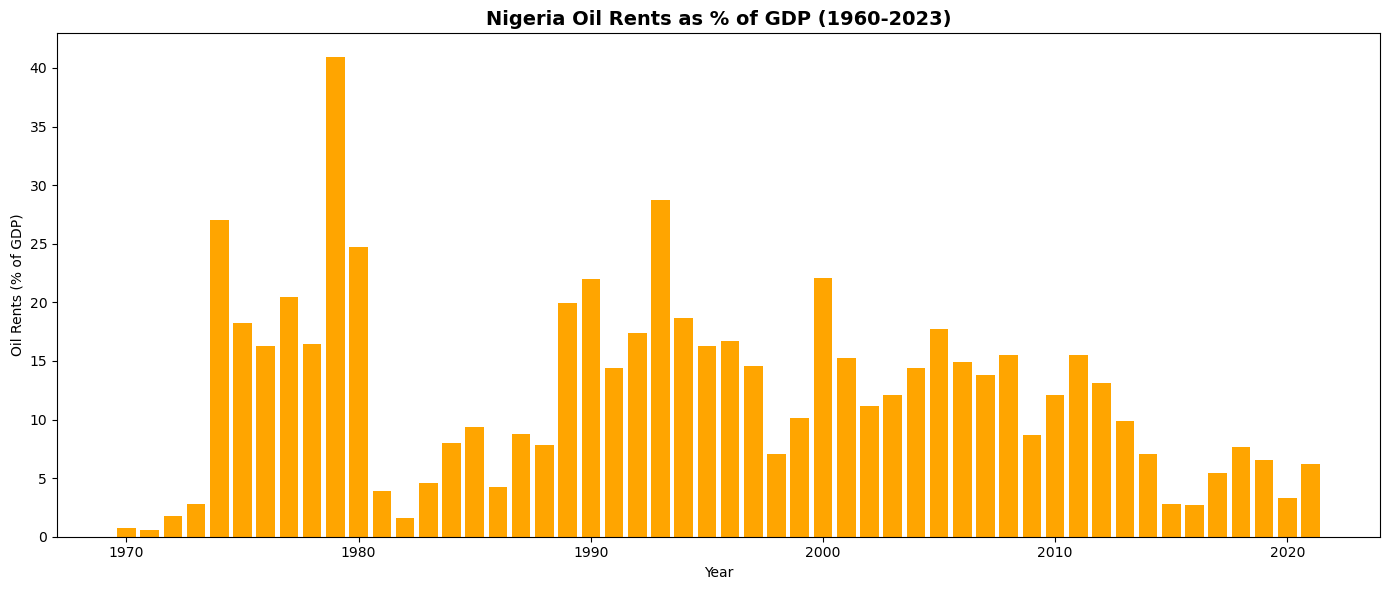

In [20]:
##  ##  Oil Rents Over Time

plt.figure(figsize=(14,6))
plt.bar(oil_rents['Year'], oil_rents['Value'], color='orange')
plt.title('Nigeria Oil Rents as % of GDP (1960-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Oil Rents (% of GDP)')
plt.tight_layout()
plt.show()

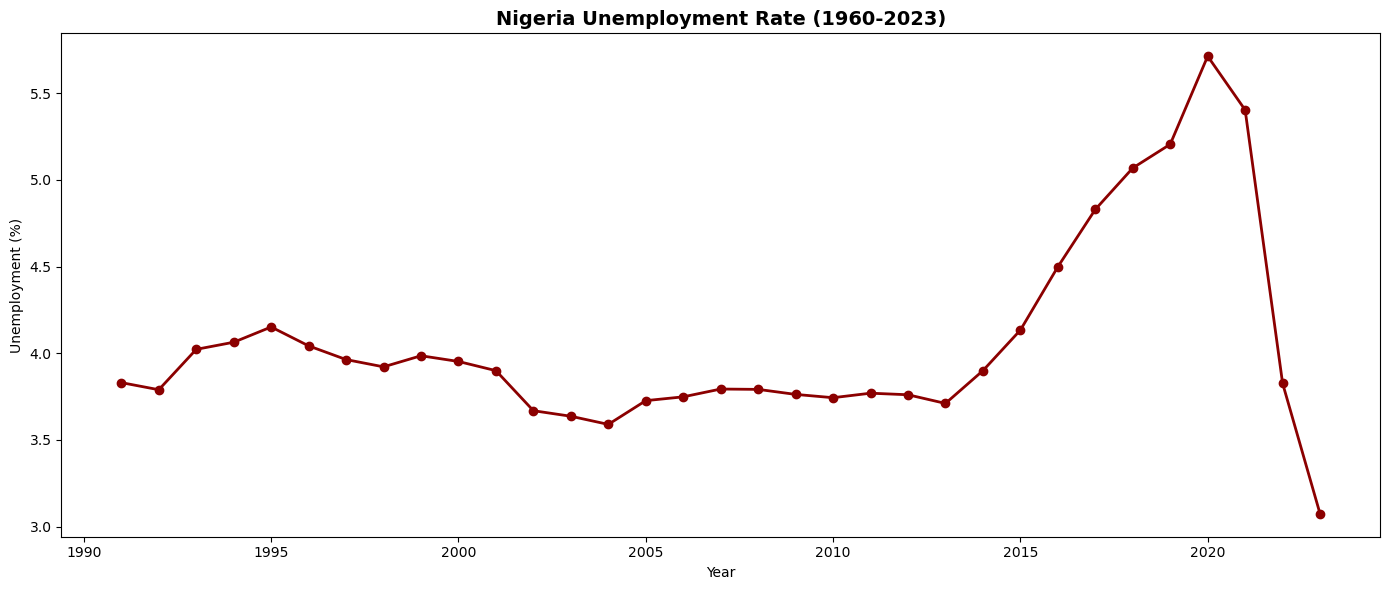

In [21]:
##  Unemployment Over Time

plt.figure(figsize=(14,6))
plt.plot(unemployment['Year'], unemployment['Value'], color='darkred', linewidth=2, marker='o')
plt.title('Nigeria Unemployment Rate (1960-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Unemployment (%)')
plt.tight_layout()
plt.show()

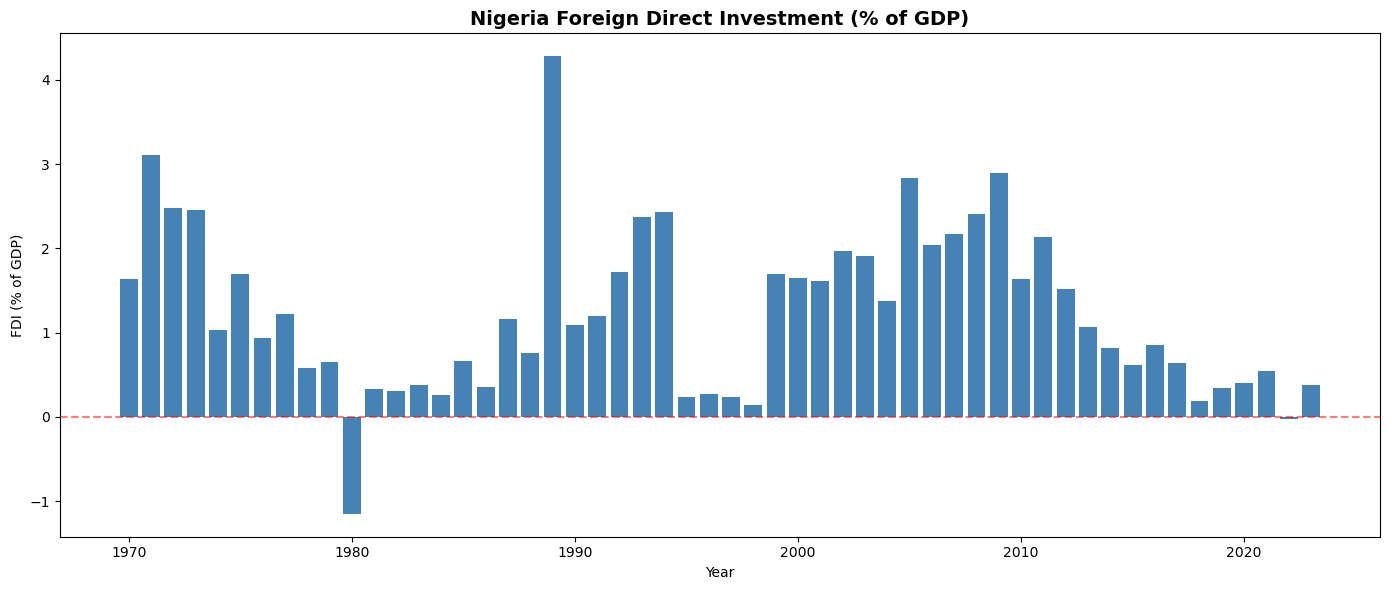

In [22]:
##   FDI Over Time

plt.figure(figsize=(14,6))
plt.bar(fdi['Year'], fdi['Value'], color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Nigeria Foreign Direct Investment (% of GDP)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('FDI (% of GDP)')
plt.tight_layout()
plt.show()

In [23]:
df_final = pd.concat([
    gdp_growth, inflation, exchange_rate, unemployment,
    gdp_per_capita, population, oil_rents, fdi, debt, govt_spending, poverty
])
df_final.to_csv('nigeria_economy_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully


In [24]:
## Poverty Rate Analysis

print("=== POVERTY ANALYSIS ===")
print(poverty[['Year', 'Value']].dropna().to_string())

=== POVERTY ANALYSIS ===
     Year  Value
648  2018   40.1
692  2022   56.2


In [25]:
##   Population vs GDP Comparison

print("=== POPULATION VS GDP PER CAPITA ===")
pop_gdp = pd.merge(
    population[['Year', 'Value']].rename(columns={'Value': 'Population'}),
    gdp_per_capita[['Year', 'Value']].rename(columns={'Value': 'GDP_Per_Capita'}),
    on='Year'
)
print(pop_gdp)

=== POPULATION VS GDP PER CAPITA ===
    Year   Population  GDP_Per_Capita
0   1960   45053782.0       93.137009
1   1961   45989310.0       97.137528
2   1962   46965292.0      104.532496
3   1963   47973575.0      107.675741
4   1964   49012016.0      113.297346
..   ...          ...             ...
59  2019  209485641.0     3189.812865
60  2020  213996181.0     2797.184581
61  2021  218529286.0     2787.487792
62  2022  223150896.0     2899.160475
63  2023  227882945.0     2138.763837

[64 rows x 3 columns]


In [26]:
##  Fuel Subsidy Removal Impact

print("=== FUEL SUBSIDY REMOVAL IMPACT 2023 ===")
print(f"Inflation 2022: {inflation[inflation['Year']==2022]['Value'].values[0]:.2f}%")
print(f"Inflation 2023: {inflation[inflation['Year']==2023]['Value'].values[0]:.2f}%")
print(f"Exchange Rate 2022: {exchange_rate[exchange_rate['Year']==2022]['Value'].values[0]:.2f}")
print(f"Exchange Rate 2023: {exchange_rate[exchange_rate['Year']==2023]['Value'].values[0]:.2f}")

=== FUEL SUBSIDY REMOVAL IMPACT 2023 ===
Inflation 2022: 18.85%
Inflation 2023: 24.66%
Exchange Rate 2022: 425.98
Exchange Rate 2023: 645.19


In [27]:
##  Pre and Post 2023 Election Comparison

print("=== PRE AND POST 2023 ELECTION ===")
print(f"GDP Growth 2022: {gdp_growth[gdp_growth['Year']==2022]['Value'].values[0]:.2f}%")
print(f"GDP Growth 2023: {gdp_growth[gdp_growth['Year']==2023]['Value'].values[0]:.2f}%")
print(f"Inflation 2022: {inflation[inflation['Year']==2022]['Value'].values[0]:.2f}%")
print(f"Inflation 2023: {inflation[inflation['Year']==2023]['Value'].values[0]:.2f}%")
print(f"Unemployment 2022: {unemployment[unemployment['Year']==2022]['Value'].values[0]:.2f}%")
print(f"Unemployment 2023: {unemployment[unemployment['Year']==2023]['Value'].values[0]:.2f}%")

=== PRE AND POST 2023 ELECTION ===
GDP Growth 2022: 4.32%
GDP Growth 2023: 3.33%
Inflation 2022: 18.85%
Inflation 2023: 24.66%
Unemployment 2022: 3.83%
Unemployment 2023: 3.07%


In [28]:
poverty_data = poverty[['Year', 'Value']].dropna()
pop_gdp = pd.merge(
    population[['Year', 'Value']].rename(columns={'Value': 'Population'}),
    gdp_per_capita[['Year', 'Value']].rename(columns={'Value': 'GDP_Per_Capita'}),
    on='Year'
)
pop_gdp['Population_Millions'] = pop_gdp['Population'] / 1000000
print('Data recreated successfully')

Data recreated successfully


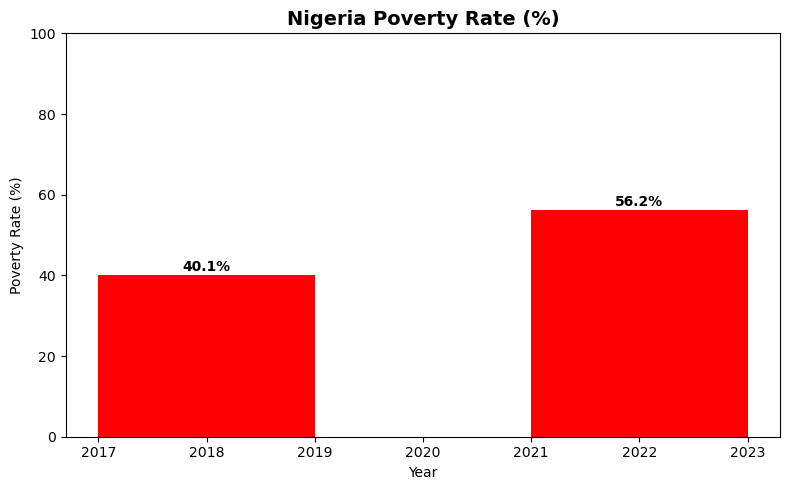

In [29]:
##  Poverty Rate Chart

plt.figure(figsize=(8,5))
plt.bar(poverty_data['Year'], poverty_data['Value'], color='red', width=2)
plt.title('Nigeria Poverty Rate (%)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Poverty Rate (%)')
plt.ylim(0, 100)
for i, row in poverty_data.iterrows():
    plt.text(row['Year'], row['Value']+1, f"{row['Value']}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

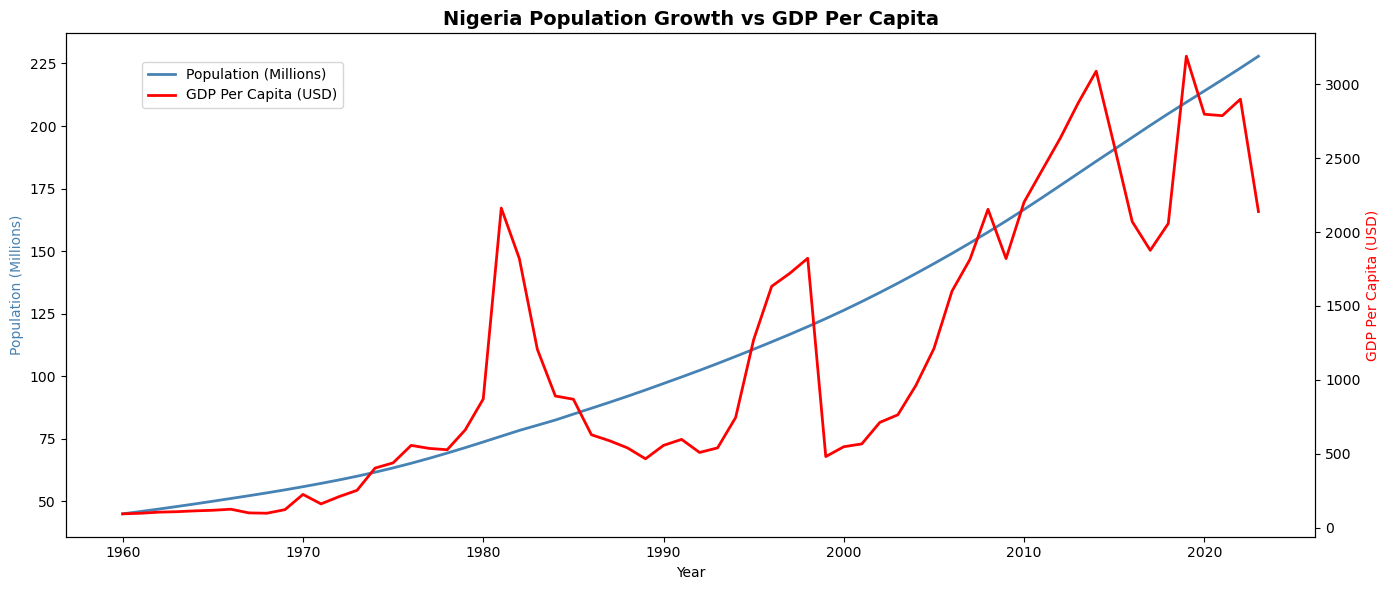

In [30]:
##  Population vs GDP Per Capita

fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(pop_gdp['Year'], pop_gdp['Population_Millions'], color='steelblue', linewidth=2, label='Population (Millions)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population (Millions)', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(pop_gdp['Year'], pop_gdp['GDP_Per_Capita'], color='red', linewidth=2, label='GDP Per Capita (USD)')
ax2.set_ylabel('GDP Per Capita (USD)', color='red')
plt.title('Nigeria Population Growth vs GDP Per Capita', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

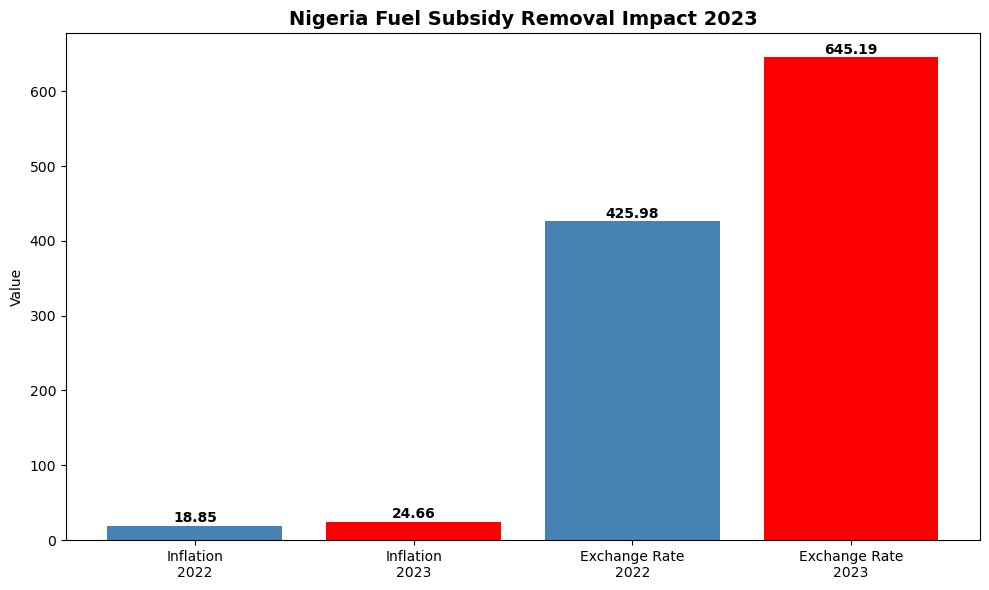

In [31]:
##  Fuel Subsidy Removal Impact

categories = ['Inflation\n2022', 'Inflation\n2023', 'Exchange Rate\n2022', 'Exchange Rate\n2023']
values = [18.85, 24.66, 425.98, 645.19]
colors = ['steelblue', 'red', 'steelblue', 'red']
plt.figure(figsize=(10,6))
bars = plt.bar(categories, values, color=colors)
plt.title('Nigeria Fuel Subsidy Removal Impact 2023', fontsize=14, fontweight='bold')
plt.ylabel('Value')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+5,
             f'{val}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

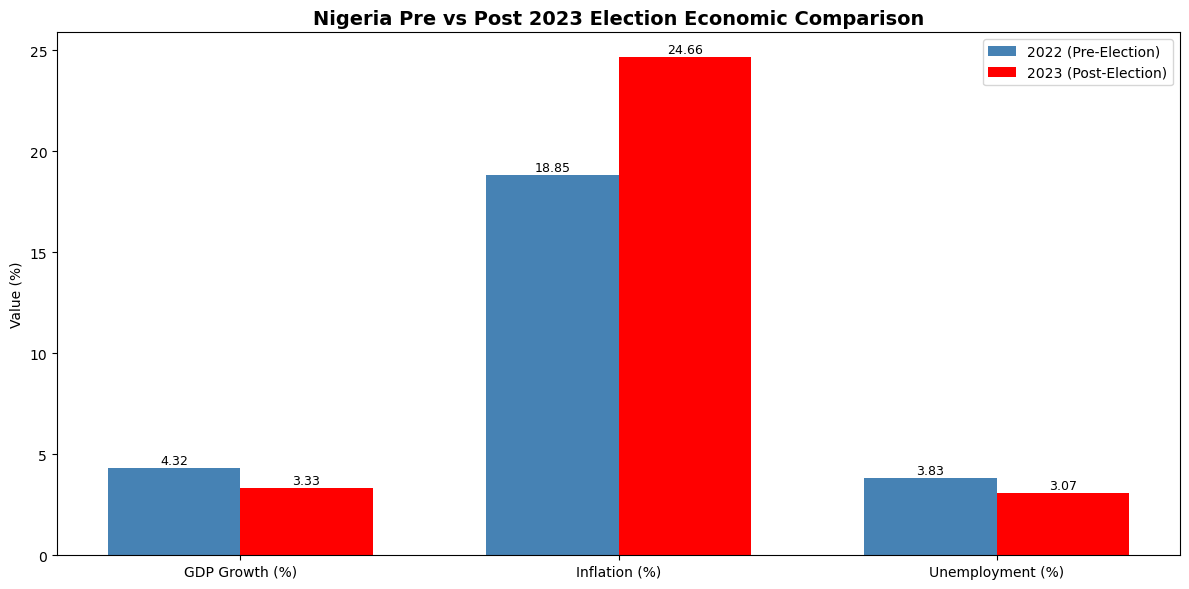

In [32]:
##   Pre and Post 2023 Election Comparison

metrics = ['GDP Growth (%)', 'Inflation (%)', 'Unemployment (%)']
values_2022 = [4.32, 18.85, 3.83]
values_2023 = [3.33, 24.66, 3.07]
x = range(len(metrics))
width = 0.35
plt.figure(figsize=(12,6))
bars1 = plt.bar([i - width/2 for i in x], values_2022, width, label='2022 (Pre-Election)', color='steelblue')
bars2 = plt.bar([i + width/2 for i in x], values_2023, width, label='2023 (Post-Election)', color='red')
plt.title('Nigeria Pre vs Post 2023 Election Economic Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, metrics)
plt.ylabel('Value (%)')
plt.legend()
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.2,
             f'{bar.get_height()}', ha='center', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.2,
             f'{bar.get_height()}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
wdi = pd.read_csv('WDIData.csv')
print(wdi.shape)
print(wdi.columns.tolist())

(422136, 64)
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', 'Unnamed: 63']


In [34]:
##   Filter for 4 African countries

countries = ['Nigeria', 'Ghana', 'Kenya', 'South Africa']
indicators = [
    'GDP growth (annual %)',
    'Inflation, consumer prices (annual %)',
    'GDP per capita (current US$)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)'
]

africa = wdi[
    (wdi['Country Name'].isin(countries)) &
    (wdi['Indicator Name'].isin(indicators))
]

print(africa.shape)
print(africa['Country Name'].unique())
print(africa['Indicator Name'].unique())

(16, 64)
['Ghana' 'Kenya' 'Nigeria' 'South Africa']
['GDP growth (annual %)' 'GDP per capita (current US$)'
 'Inflation, consumer prices (annual %)'
 'Unemployment, total (% of total labor force) (modeled ILO estimate)']


In [35]:
##  Reshape to long format

africa_melted = africa.melt(
    id_vars=['Country Name', 'Indicator Name'],
    value_vars=[str(y) for y in range(1990, 2019)],
    var_name='Year',
    value_name='Value'
)
africa_melted['Year'] = africa_melted['Year'].astype(int)
africa_melted['Value'] = pd.to_numeric(africa_melted['Value'], errors='coerce')
africa_melted = africa_melted.dropna()
print(africa_melted.head())
print(africa_melted.shape)

  Country Name                         Indicator Name  Year       Value
0        Ghana                  GDP growth (annual %)  1990    3.328818
1        Ghana           GDP per capita (current US$)  1990  402.588881
2        Ghana  Inflation, consumer prices (annual %)  1990   37.259066
4        Kenya                  GDP growth (annual %)  1990    4.192051
5        Kenya           GDP per capita (current US$)  1990  366.300891
(448, 4)


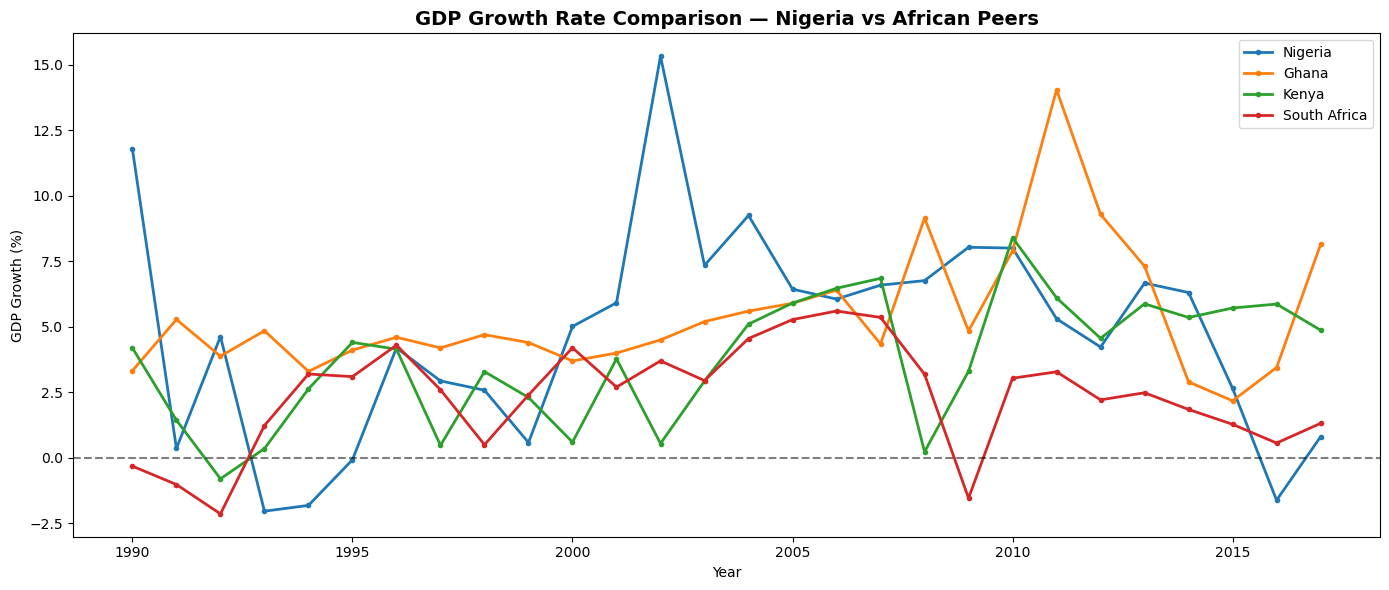

In [36]:
##   GDP Growth Comparison

gdp_compare = africa_melted[africa_melted['Indicator Name'] == 'GDP growth (annual %)']

plt.figure(figsize=(14,6))
for country in countries:
    data = gdp_compare[gdp_compare['Country Name'] == country]
    plt.plot(data['Year'], data['Value'], linewidth=2, label=country, marker='o', markersize=3)
plt.title('GDP Growth Rate Comparison — Nigeria vs African Peers', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

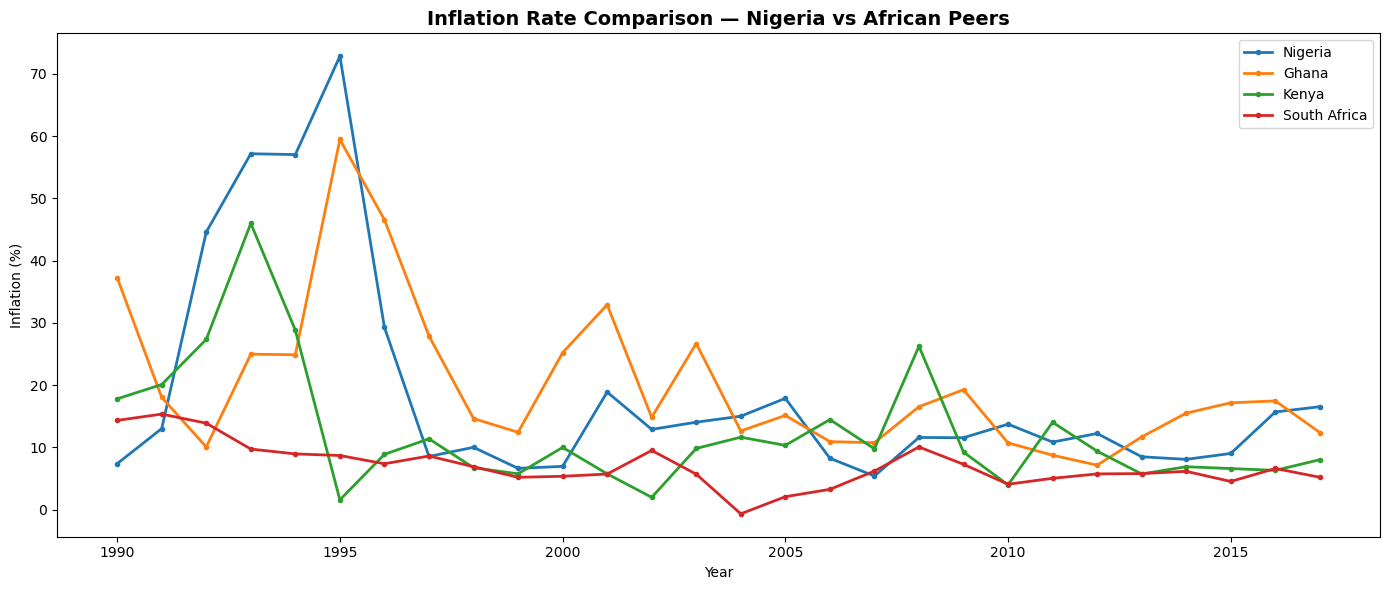

In [37]:
##   Inflation Comparison

inflation_compare = africa_melted[africa_melted['Indicator Name'] == 'Inflation, consumer prices (annual %)']

plt.figure(figsize=(14,6))
for country in countries:
    data = inflation_compare[inflation_compare['Country Name'] == country]
    plt.plot(data['Year'], data['Value'], linewidth=2, label=country, marker='o', markersize=3)
plt.title('Inflation Rate Comparison — Nigeria vs African Peers', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.legend()
plt.tight_layout()
plt.show()

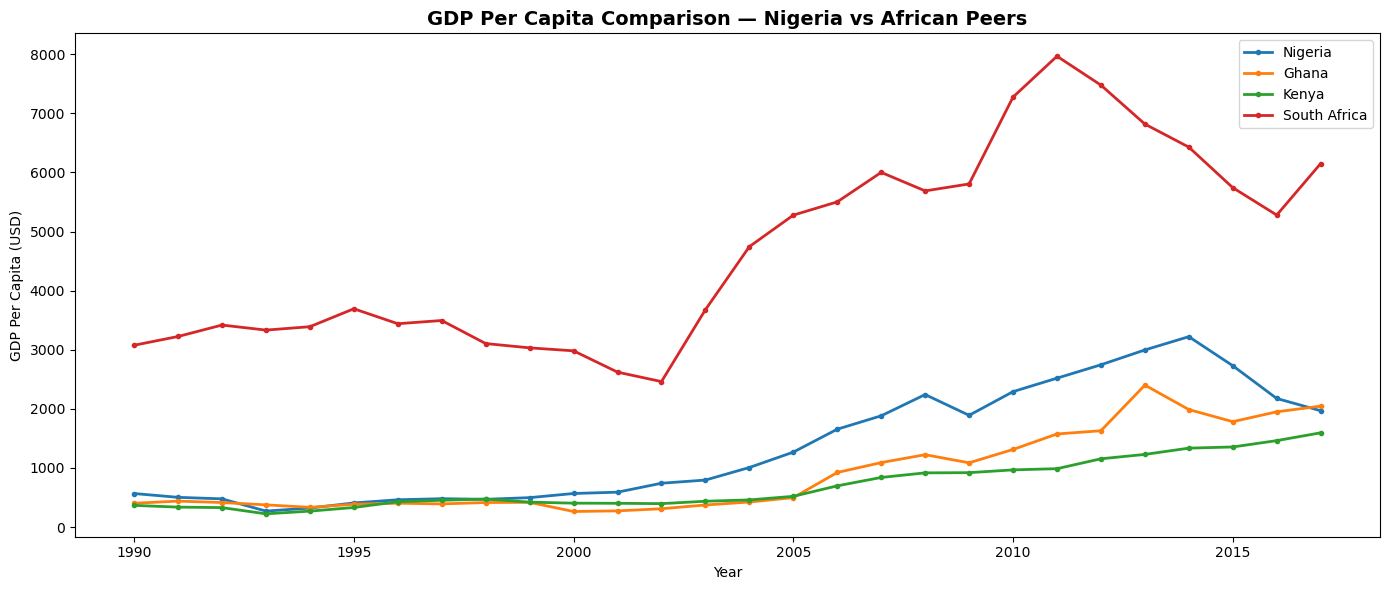

In [38]:
##  GDP Per Capita Comparison

gdp_capita_compare = africa_melted[africa_melted['Indicator Name'] == 'GDP per capita (current US$)']

plt.figure(figsize=(14,6))
for country in countries:
    data = gdp_capita_compare[gdp_capita_compare['Country Name'] == country]
    plt.plot(data['Year'], data['Value'], linewidth=2, label=country, marker='o', markersize=3)
plt.title('GDP Per Capita Comparison — Nigeria vs African Peers', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('GDP Per Capita (USD)')
plt.legend()
plt.tight_layout()
plt.show()

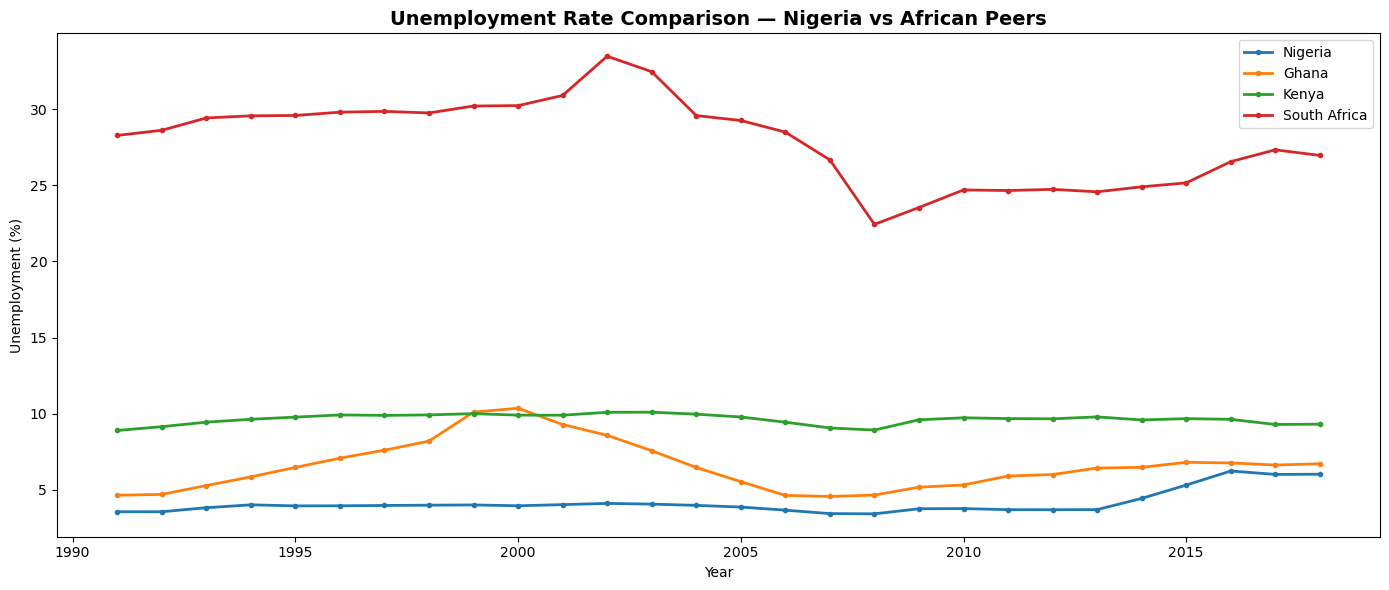

In [39]:
##  Unemployment Comparison

unemp_compare = africa_melted[africa_melted['Indicator Name'] == 'Unemployment, total (% of total labor force) (modeled ILO estimate)']

plt.figure(figsize=(14,6))
for country in countries:
    data = unemp_compare[unemp_compare['Country Name'] == country]
    plt.plot(data['Year'], data['Value'], linewidth=2, label=country, marker='o', markersize=3)
plt.title('Unemployment Rate Comparison — Nigeria vs African Peers', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Unemployment (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
africa_melted.to_csv('africa_comparison_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully
